## Load dataset

In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql import functions as F
import numpy as np
import matplotlib.pyplot as plt
from pyspark.ml.evaluation import ClusteringEvaluator
import pandas as pd
from pyspark.ml.clustering import KMeans

In [2]:
spark = SparkSession.builder.appName("FlightProject").getOrCreate()

df = spark.read.parquet("/Users/huynhphuongchi/Desktop/Unipi/Distributed data Analysis and Mining/flights_cleaned.parquet")
df.createOrReplaceTempView("flight_cleaned")

df.printSchema()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/16 04:04:37 WARN Utils: Your hostname, MacBook-Pro-cua-Huynh.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.185 instead (on interface en0)
26/03/16 04:04:37 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/16 04:04:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/16 04:04:38 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/16 04:04:38 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


root
 |-- DEP_DELAY: double (nullable = true)
 |-- TAXI_OUT: double (nullable = true)
 |-- TAXI_IN: double (nullable = true)
 |-- ARR_DELAY: double (nullable = true)
 |-- DISTANCE: double (nullable = true)
 |-- Hour: long (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- DELAYED: integer (nullable = true)
 |-- ROUTE: string (nullable = true)
 |-- AIRPORT_DELAY_RATE: double (nullable = true)
 |-- ROUTE_DELAY_RATE: double (nullable = true)
 |-- AIRLINE_DELAY_RATE: double (nullable = true)



In [3]:
df.show()

+---------+--------+-------+---------+--------+----+---------+-----+-------+-------+-------------------+-------------------+-------------------+
|DEP_DELAY|TAXI_OUT|TAXI_IN|ARR_DELAY|DISTANCE|Hour|DayOfWeek|Month|DELAYED|  ROUTE| AIRPORT_DELAY_RATE|   ROUTE_DELAY_RATE| AIRLINE_DELAY_RATE|
+---------+--------+-------+---------+--------+----+---------+-----+-------+-------+-------------------+-------------------+-------------------+
|      3.0|    26.0|    3.0|      0.0|   338.0|  10|        1|    6|      0|SNA_PHX|0.17688820460183047|0.17723718505647262|0.18472421952357954|
|     22.0|    10.0|    4.0|     11.0|   338.0|  21|        6|    7|      1|SNA_PHX|0.17688820460183047|0.17723718505647262|0.18472421952357954|
|     -5.0|     8.0|    8.0|     -8.0|   338.0|  20|        6|   12|      0|SNA_PHX|0.17688820460183047|0.17723718505647262|0.18472421952357954|
|      1.0|     8.0|    3.0|    -18.0|   338.0|  17|        2|   11|      0|SNA_PHX|0.17688820460183047|0.17723718505647262|0.1847

In [4]:
num_cores = spark.sparkContext.defaultParallelism
print(f"Spark is using {num_cores} cores.")

Spark is using 10 cores.


In [5]:
df.rdd.getNumPartitions()

11

In [ ]:
df_cluster = df.repartition(20)
spark.conf.set("spark.sql.shuffle.partitions", 30)

In [7]:
df_cluster.cache()
df_cluster.count()

1931907

# Pre-Processingg

In [ ]:
input_cols = [ "TAXI_OUT", "TAXI_IN", "DISTANCE","Hour", "DayOfWeek","Month",
              "AIRPORT_DELAY_RATE", "ROUTE_DELAY_RATE", "AIRLINE_DELAY_RATE","ARR_DELAY"]

In [9]:
assembler = VectorAssembler(inputCols=input_cols, outputCol="raw_features")
df_vector = assembler.transform(df)

In [10]:
df_vector.show()

+---------+--------+-------+---------+--------+----+---------+-----+-------+-------+-------------------+-------------------+-------------------+--------------------+
|DEP_DELAY|TAXI_OUT|TAXI_IN|ARR_DELAY|DISTANCE|Hour|DayOfWeek|Month|DELAYED|  ROUTE| AIRPORT_DELAY_RATE|   ROUTE_DELAY_RATE| AIRLINE_DELAY_RATE|        raw_features|
+---------+--------+-------+---------+--------+----+---------+-----+-------+-------+-------------------+-------------------+-------------------+--------------------+
|      3.0|    26.0|    3.0|      0.0|   338.0|  10|        1|    6|      0|SNA_PHX|0.17688820460183047|0.17723718505647262|0.18472421952357954|[26.0,3.0,338.0,1...|
|     22.0|    10.0|    4.0|     11.0|   338.0|  21|        6|    7|      1|SNA_PHX|0.17688820460183047|0.17723718505647262|0.18472421952357954|[10.0,4.0,338.0,2...|
|     -5.0|     8.0|    8.0|     -8.0|   338.0|  20|        6|   12|      0|SNA_PHX|0.17688820460183047|0.17723718505647262|0.18472421952357954|[8.0,8.0,338.0,20...|
|   

In [11]:
scaler = StandardScaler(inputCol="raw_features", outputCol="features", withStd=True, withMean=True)
scaler_model = scaler.fit(df_vector)
final_df = scaler_model.transform(df_vector)

In [12]:
final_df.show()

+---------+--------+-------+---------+--------+----+---------+-----+-------+-------+-------------------+-------------------+-------------------+--------------------+--------------------+
|DEP_DELAY|TAXI_OUT|TAXI_IN|ARR_DELAY|DISTANCE|Hour|DayOfWeek|Month|DELAYED|  ROUTE| AIRPORT_DELAY_RATE|   ROUTE_DELAY_RATE| AIRLINE_DELAY_RATE|        raw_features|            features|
+---------+--------+-------+---------+--------+----+---------+-----+-------+-------+-------------------+-------------------+-------------------+--------------------+--------------------+
|      3.0|    26.0|    3.0|      0.0|   338.0|  10|        1|    6|      0|SNA_PHX|0.17688820460183047|0.17723718505647262|0.18472421952357954|[26.0,3.0,338.0,1...|[1.10339342395038...|
|     22.0|    10.0|    4.0|     11.0|   338.0|  21|        6|    7|      1|SNA_PHX|0.17688820460183047|0.17723718505647262|0.18472421952357954|[10.0,4.0,338.0,2...|[-0.7604386814669...|
|     -5.0|     8.0|    8.0|     -8.0|   338.0|  20|        6|   

# Elbow

In [13]:
wssse = {}
silhouette = {}
centers = {}

k_values = range(2, 21)

for k in k_values:

    kmeans = KMeans(
        featuresCol="features",
        k=k)

    model = kmeans.fit(final_df)

    # WSSSE
    summary = model.summary
    wssse[k] = summary.trainingCost

    # Predictions
    predictions = model.transform(final_df)

    # Silhouette score
    evaluator = ClusteringEvaluator(featuresCol="features")
    silhouette[k] = evaluator.evaluate(predictions)

    # Cluster centers
    centers[k] = model.clusterCenters()

    print(f"k = {k}, WSSSE = {wssse[k]}, Silhouette = {silhouette[k]}")

26/03/16 04:04:59 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/03/16 04:05:09 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


k = 2, WSSSE = 16841924.369465277, Silhouette = 0.24046811639374224


k = 3, WSSSE = 15667057.829378946, Silhouette = 0.2254587082088891


k = 4, WSSSE = 15072355.675760033, Silhouette = 0.14488653259036413


k = 5, WSSSE = 13890121.392736038, Silhouette = 0.16015740861035097


...

k = 16, WSSSE = 9727407.502516035, Silhouette = 0.16184308708888145


k = 17, WSSSE = 9732691.893140651, Silhouette = 0.1712361114037949


k = 18, WSSSE = 9413023.43810422, Silhouette = 0.16331675576981783


k = 19, WSSSE = 9402666.003548972, Silhouette = 0.17046831740976903


k = 20, WSSSE = 9178588.939632805, Silhouette = 0.16745449575248758


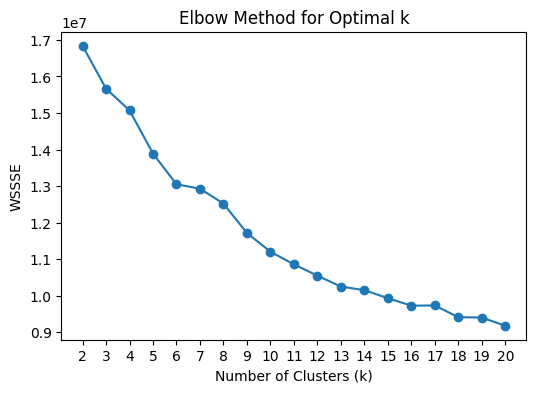

In [14]:
plt.figure(figsize=(6,4))

plt.plot(
    list(wssse.keys()),
    list(wssse.values()),
    marker='o'
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WSSSE")
plt.title("Elbow Method for Optimal k")

plt.xticks(list(wssse.keys()))

plt.show()

# K-Means

In [15]:
kmeans = KMeans(
    k=5,
    featuresCol="features",
    seed=42,
    maxIter=50,    
    initSteps=5    
)

model = kmeans.fit(final_df)

clusters = model.transform(final_df)

In [16]:
clusters.groupBy("prediction").count().show()

+----------+------+
|prediction| count|
+----------+------+
|         3|882088|
|         1|545176|
|         0|160960|
|         2|227695|
|         4|115988|
+----------+------+



In [ ]:
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="prediction")

silhouette = evaluator.evaluate(clusters)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.24171390468522772


In [18]:
centers = model.clusterCenters()

for i, c in enumerate(centers):
    print(f"Cluster {i}: {c}")

Cluster 0: [ 2.37225213e+00 -1.24754366e-01 -2.47030403e-01  2.88525097e-02
 -1.53894765e-03 -1.12037557e-01  5.16857107e-02  1.41143725e-01
 -2.59105890e-01  5.06782615e-01]
Cluster 1: [-0.22505501 -0.21408167  0.04332643  0.08801674  0.00265098 -0.0079968
  1.01535873  0.88104756  0.7079496  -0.08396492]
Cluster 2: [ 1.57028181e-03  3.16857927e-02  1.97379674e+00 -4.15122792e-02
  1.65812206e-02  3.45644749e-03 -1.70169762e-01 -5.36625644e-02
  1.35558698e-01 -2.15234203e-01]
Cluster 3: [-0.28833482 -0.15377127 -0.49247887 -0.06714805 -0.0055324   0.02270889
 -0.58151227 -0.57624439 -0.44824617 -0.24323368]
Cluster 4: [-4.45527086e-02  2.28744500e+00  9.48085486e-03  1.38450222e-01
 -8.03949185e-04  1.35867898e-02 -8.79100789e-02  1.50559895e-01
  1.74743768e-01  1.96442606e+00]


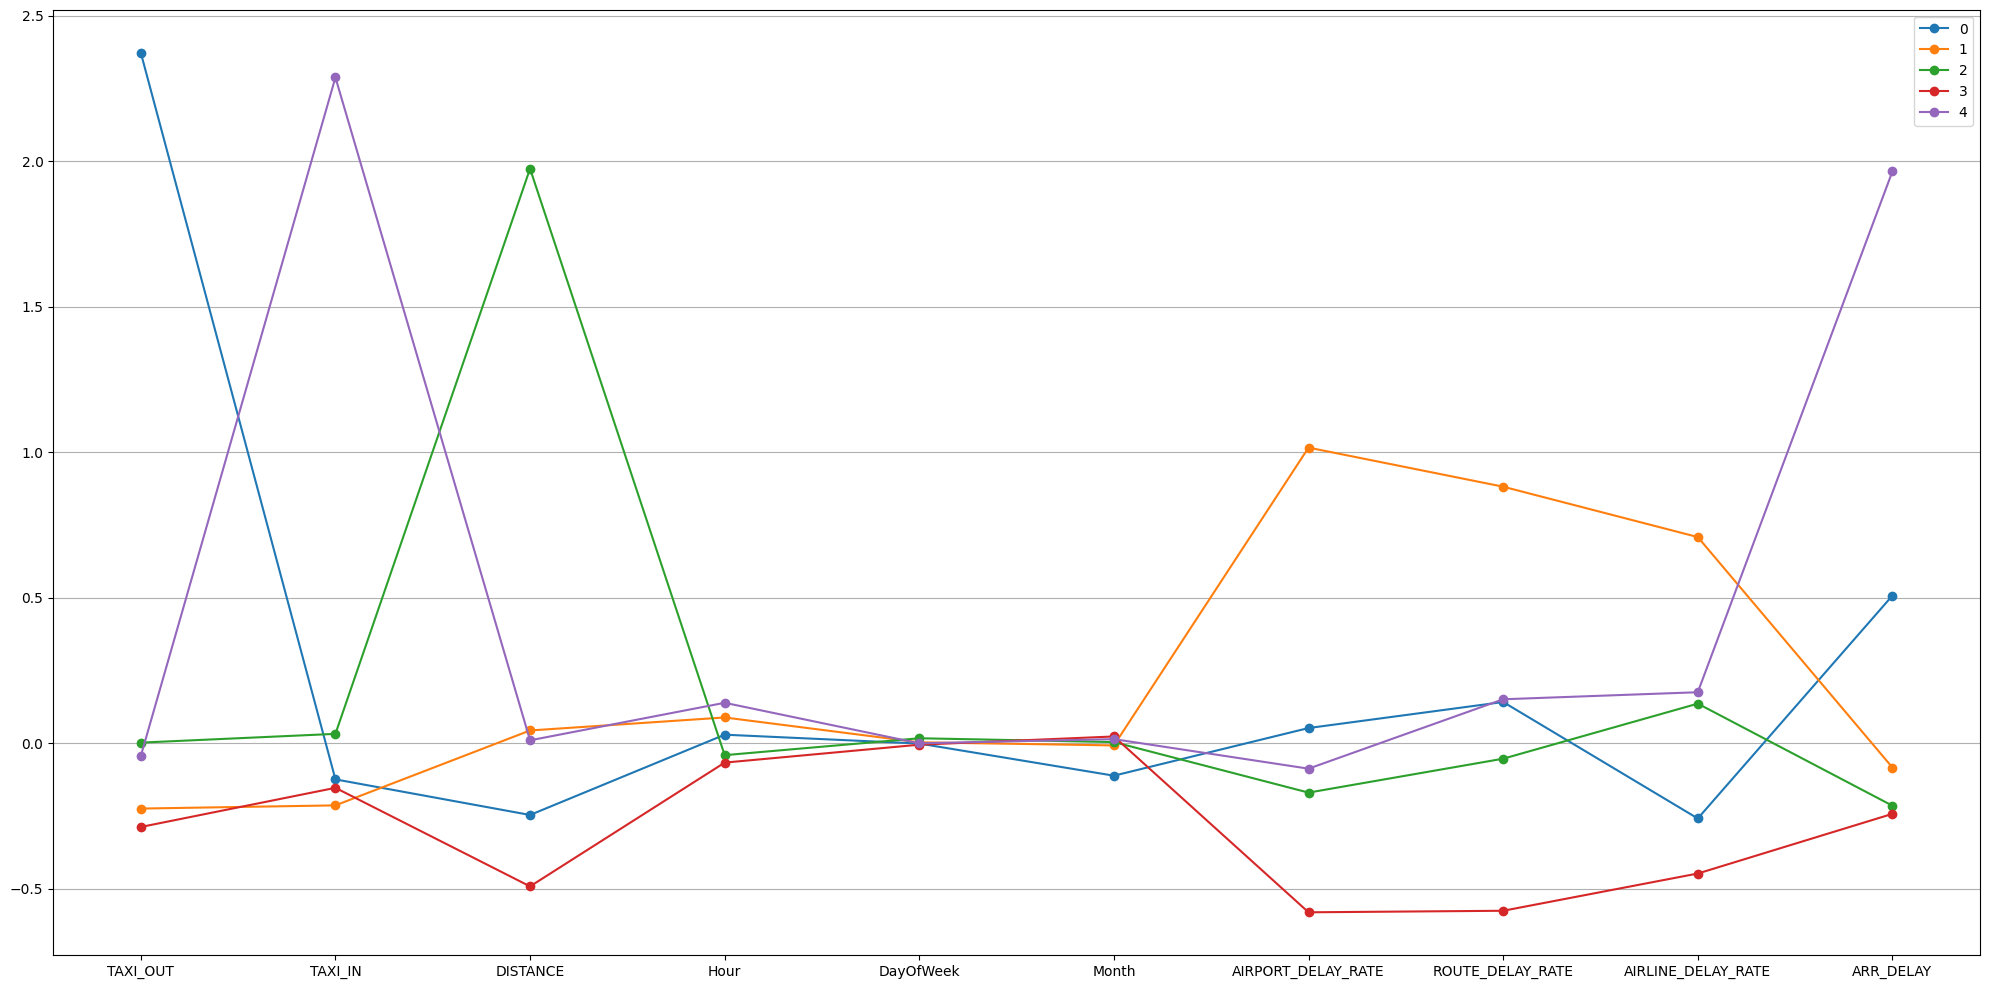

In [ ]:
centers_df = pd.DataFrame(centers, columns=input_cols)
centers_df.T.plot(figsize=(20,10), marker='o')

plt.xticks(
    np.arange(len(input_cols)),
    input_cols)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# PCA MAP

In [20]:
from pyspark.ml.feature import PCA
pca = PCA(k=2, inputCol="features", outputCol="pcaFeatures")
pca_model = pca.fit(clusters)
pca_df = pca_model.transform(clusters)

26/03/16 04:07:47 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


In [ ]:
from pyspark.sql.functions import col
from pyspark.ml.functions import vector_to_array

pca_points = pca_df.select(
    col("prediction"),
    vector_to_array("pcaFeatures")[0].alias("PC1"),
    vector_to_array("pcaFeatures")[1].alias("PC2"))

In [22]:
pca_pd = pca_points.toPandas()

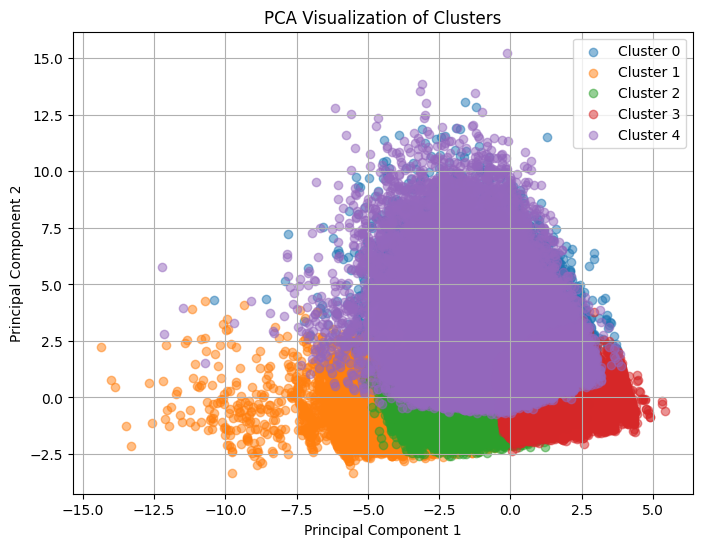

26/03/16 11:39:00 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 3651449 ms exceeds timeout 120000 ms
26/03/16 11:39:00 WARN SparkContext: Killing executors is not supported by current scheduler.
26/03/16 11:39:03 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:81)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:674)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1363)
	at 

In [ ]:
plt.figure(figsize=(8,6))

for cluster in sorted(pca_pd["prediction"].unique()):
    
    subset = pca_pd[pca_pd["prediction"] == cluster]
    
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.5)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Visualization of Clusters")

plt.legend()
plt.grid()

plt.show()